# Part B: Machine Learning Models — Water Potability Classification

**Dataset:** `water_potability_cleaned.csv` (preprocessed by Part A)  
**Target:** `Potability` (0 = Not Potable, 1 = Potable)  
**Task:** Binary Classification  

**Models:**
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- k-Nearest Neighbors (kNN)
- Gradient Boosting

### Load Dataset & Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [26]:
data_path = "water_potability_cleaned.csv"
df = pd.read_csv(data_path)

print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df['Potability'].value_counts())
df.head()

Shape          : (3276, 13)
Missing values : 0

Target distribution:
Potability
0    1998
1    1278
Name: count, dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,ph_deviation,is_safe_ph,hardness_solids_ratio
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,0.080795,1,0.009854
1,3.889107,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0,3.110893,0,0.006947
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0,1.099124,1,0.011262
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,1.316766,1,0.009736
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,2.092223,0,0.010072


### Split Features (X) and Target (y)

- **X** = all columns except `Potability` (12 input features)  
- **y** = `Potability` column (0 = Not Potable, 1 = Potable)

In [27]:
X = df.drop(columns=["Potability"])
y = df["Potability"]

print(f"X shape : {X.shape}  → features")
print(f"y shape : {y.shape}  → target")
print(f"\nFeatures: {list(X.columns)}")

X shape : (3276, 12)  → features
y shape : (3276,)  → target

Features: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'ph_deviation', 'is_safe_ph', 'hardness_solids_ratio']


### Define Models & KFold

KFold with 5 splits is used instead of a fixed train/test split — this gives a more reliable performance estimate by testing on every part of the data.

`class_weight='balanced'` is set for Logistic Regression to handle the class imbalance (61% Not Potable vs 39% Potable).

In [28]:
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(random_state=42),
    'SVM'                  : SVC(random_state=42),
    'kNN'                  : KNeighborsClassifier(),
    'Gradient Boosting'    : GradientBoostingClassifier(random_state=42),
}

# Models that need StandardScaler
scaled_models = {'Logistic Regression', 'SVM', 'kNN'}

# KFold — 5 folds, shuffle before splitting
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Models defined:")
for name in models:
    tag = "  ← needs scaling" if name in scaled_models else ""
    print(f"  • {name}{tag}")
print(f"\nKFold: 5 splits, shuffle=True")

Models defined:
  • Logistic Regression  ← needs scaling
  • Decision Tree
  • Random Forest
  • SVM  ← needs scaling
  • kNN  ← needs scaling
  • Gradient Boosting

KFold: 5 splits, shuffle=True


### Hyperparameter Tuning with GridSearchCV

GridSearchCV tests every combination of hyperparameters using 5-fold cross-validation and selects the best combination based on **F1-score**.

For models that need scaling (Logistic Regression, SVM, kNN), a **Pipeline** is used so the scaler is fitted only on the training fold — this prevents data leakage.

In [29]:
param_grids = {
    'Logistic Regression': {
        'model__C'      : [0.01, 0.1, 1, 10],
        'model__solver' : ['lbfgs', 'liblinear'],
    },
    'Decision Tree': {
        'max_depth'        : [3, 5, 10, None], # try 4 different depths,max_depth = How many levels of questions the tree can ask
        'min_samples_split': [2, 5, 10], # min_samples_split, 10 means don't split if less than 10 samples
        'criterion'        : ['gini', 'entropy'], # criterion, gini or entropy — both are formulas, gini is faster
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200], # How many trees to build (more = better but slower)
        'max_depth'   : [5, 10, None], # How deep each tree can go
        'max_features': ['sqrt', 'log2'], # How many features each tree considers at each split
    },
    'SVM': {
        'model__C'     : [0.1, 1, 10], # How strict the boundary is — small C = flexible, large C = strict
        'model__kernel': ['rbf', 'linear'], # Shape of the boundary — rbf is curved, linear is straight
        'model__gamma' : ['scale', 'auto'], # How far each data point's influence reaches
    },
    'kNN': {
        'model__n_neighbors': [3, 5, 7, 11], # How many nearest neighbours to look at
        'model__weights'    : ['uniform', 'distance'], # uniform = all neighbours equal, distance = closer neighbours matter more
        'model__metric'     : ['euclidean', 'manhattan'], # How to measure distance — euclidean (straight line) or manhattan (grid steps)
    },
    'Gradient Boosting': {
        'n_estimators' : [50, 100, 200], # How many trees to build one after another
        'learning_rate': [0.05, 0.1, 0.2], # How fast it learns — smaller is slower but more careful
        'max_depth'    : [3, 5], # How deep each tree can go
    },
}

best_params = {} # will store the winning settings for each model
best_models = {} # will store the trained model with winning settings

for name, model in models.items():

    # Use Pipeline for models that need scaling
    # This ensures the scaler only sees training data in each fold (no data leakage)
    if name in scaled_models:
        estimator = Pipeline([
            ('scaler', StandardScaler()),
            ('model',  model)
        ])
    else:
        estimator = model

    grid = GridSearchCV(estimator, param_grids[name], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X, y)

    best_params[name] = grid.best_params_ # save the winning settings
    best_models[name] = grid.best_estimator_ # save the model trained with those settings

    print(f"{name}")
    print(f"  Best params : {grid.best_params_}")
    print(f"  Best F1     : {grid.best_score_:.4f}")
    print()

print("Hyperparameter tuning complete!")

Logistic Regression
  Best params : {'model__C': 1, 'model__solver': 'lbfgs'}
  Best F1     : 0.4665

Decision Tree
  Best params : {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5}
  Best F1     : 0.4490

Random Forest
  Best params : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}
  Best F1     : 0.3759

SVM
  Best params : {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
  Best F1     : 0.4334

kNN
  Best params : {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'distance'}
  Best F1     : 0.3943

Gradient Boosting
  Best params : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
  Best F1     : 0.4076

Hyperparameter tuning complete!


## Evaluate Best Models Using KFold

Using the best models found by GridSearchCV, we now evaluate each model across all 5 folds and average the results.

For models using a Pipeline, the scaler is fitted fresh on each training fold — ensuring no leakage.

In [30]:
results = {}

for name, model in best_models.items():
    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    for train_idx, test_idx in kf.split(X, y):

        X_train_fold = X.iloc[train_idx]
        X_test_fold  = X.iloc[test_idx]
        y_train_fold = y.iloc[train_idx]
        y_test_fold  = y.iloc[test_idx]

        # If it's a Pipeline, it handles scaling internally
        # If it's a plain model (DT, RF, GB), no scaling needed
        if name in scaled_models:
            # Re-create pipeline per fold to fit scaler only on train fold
            base_model = models[name]
            pipe = Pipeline([('scaler', StandardScaler()), ('model', base_model)])
            pipe.set_params(**{k: v for k, v in best_params[name].items()})
            pipe.fit(X_train_fold, y_train_fold)
            y_pred = pipe.predict(X_test_fold)
        else:
            model.fit(X_train_fold, y_train_fold)
            y_pred = model.predict(X_test_fold)

        acc_list.append (accuracy_score (y_test_fold, y_pred))
        prec_list.append(precision_score(y_test_fold, y_pred, zero_division=0))
        rec_list.append (recall_score   (y_test_fold, y_pred, zero_division=0))
        f1_list.append  (f1_score       (y_test_fold, y_pred, zero_division=0))

    results[name] = {
        'Accuracy'  : round(np.mean(acc_list),  4),
        'Precision' : round(np.mean(prec_list), 4),
        'Recall'    : round(np.mean(rec_list),  4),
        'F1-Score'  : round(np.mean(f1_list),   4),
    }

    print(f"{name:25s} → Accuracy: {np.mean(acc_list):.4f}  "
          f"Precision: {np.mean(prec_list):.4f}  "
          f"Recall: {np.mean(rec_list):.4f}  "
          f"F1: {np.mean(f1_list):.4f}")

Logistic Regression       → Accuracy: 0.5067  Precision: 0.4021  Recall: 0.5479  F1: 0.4635
Decision Tree             → Accuracy: 0.5693  Precision: 0.4469  Recall: 0.4462  F1: 0.4463
Random Forest             → Accuracy: 0.6560  Precision: 0.6132  Recall: 0.3268  F1: 0.4258
SVM                       → Accuracy: 0.6624  Precision: 0.6022  Recall: 0.4075  F1: 0.4846
kNN                       → Accuracy: 0.6151  Precision: 0.5075  Recall: 0.4170  F1: 0.4576
Gradient Boosting         → Accuracy: 0.6502  Precision: 0.5701  Recall: 0.4157  F1: 0.4807


## Model Comparison Table

In [31]:
results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
model_names = list(results_df.index)

print("MODEL COMPARISON TABLE (sorted by F1-Score)")
print("=" * 60)
print(results_df.to_string())
print()
print(f">>> Best model  : {results_df.index[0]}  (F1 = {results_df['F1-Score'].iloc[0]})")
print(f">>> Worst model : {results_df.index[-1]}  (F1 = {results_df['F1-Score'].iloc[-1]})")

MODEL COMPARISON TABLE (sorted by F1-Score)
                     Accuracy  Precision  Recall  F1-Score
SVM                    0.6624     0.6022  0.4075    0.4846
Gradient Boosting      0.6502     0.5701  0.4157    0.4807
Logistic Regression    0.5067     0.4021  0.5479    0.4635
kNN                    0.6151     0.5075  0.4170    0.4576
Decision Tree          0.5693     0.4469  0.4462    0.4463
Random Forest          0.6560     0.6132  0.3268    0.4258

>>> Best model  : SVM  (F1 = 0.4846)
>>> Worst model : Random Forest  (F1 = 0.4258)


## Visualisation: Bar Chart

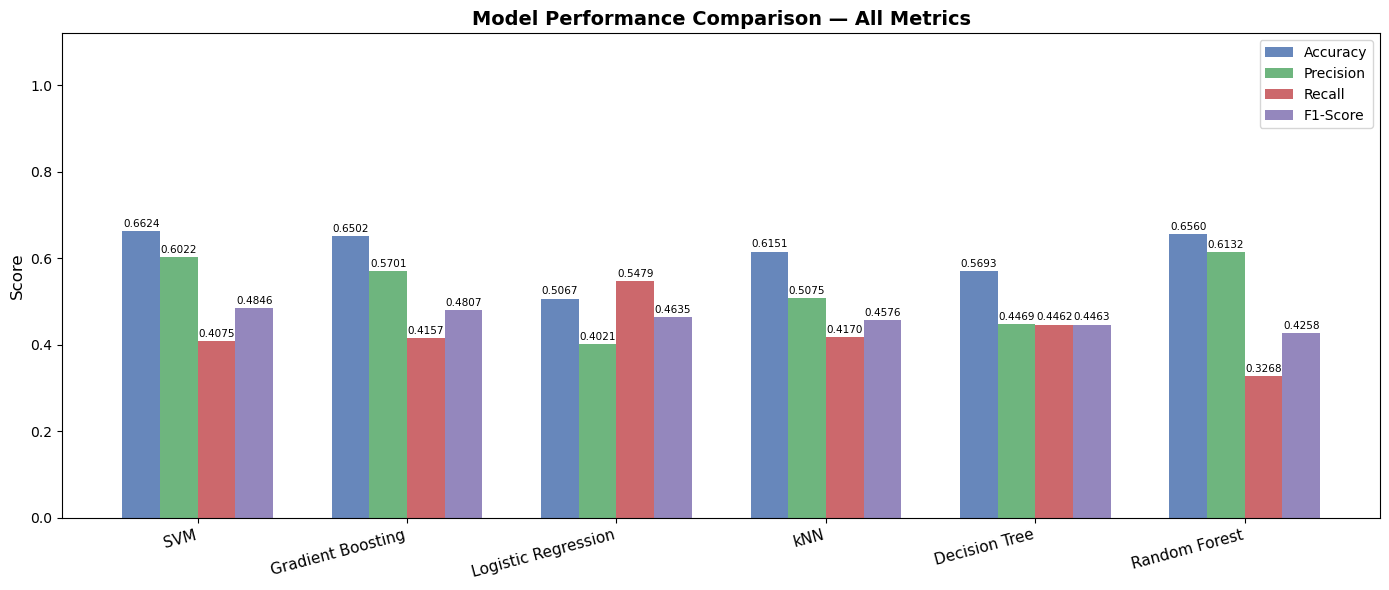

In [32]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(model_names))
width = 0.18

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Performance Analysis

### Overall Comparison
Based on the table, SVM achieved the highest accuracy (0.6624), followed by Random Forest (0.6560) and Gradient Boosting (0.6502). 

When considering F1-Score, which balances precision and recall, SVM ranked best (0.4846), followed by Gradient Boosting (0.4807) and Logistic Regression (0.4635).

### Best Model
SVM is selected as the best overall model based on its highest accuracy (0.6624) and the highest F1-Score (0.4846). 

Although Random Forest achieved the highest precision (0.6132), SVM maintained a more balanced performance across all four metrics, making it the most reliable model overall.

### Worst Model
Random Forest had the lowest F1-Score (0.4258) and the lowest recall (0.3268), meaning it missed the most actual potable water samples, it classifying them incorrectly as not potable. 

Logistic Regression had the lowest accuracy (0.5067), performing only slightly better than random guessing.

### Key Observation
All models show a noticeable gap between accuracy and recall. This is likely caused by the class imbalance in the dataset (61% non-potable
vs 39% potable), where models tend to favour predicting the majority class (not potable).

In water safety applications, a low recall is particularly dangerous since it means the model fails to detect unsafe water, posing a health risk
to consumers. Therefore, a model with balanced precision and recall is preferred over one with just high accuracy.

### Conclusion
SVM and Gradient Boosting are the most balanced models for this dataset, achieving the two highest F1-Scores of 0.4846 and 0.4807 respectively.